<a href="https://colab.research.google.com/github/susmitsingh01/triton-llm-kernels-lab/blob/main/triton-lab-notebook-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR = '/content/drive/MyDrive/triton-llm-kernels-lab'
PLOTS_DIR = os.path.join(BASE_DIR, 'plots', '02_flash_attention')

os.makedirs(PLOTS_DIR, exist_ok=True)

print(f'Base directory : {BASE_DIR}')
print(f'Plots directory: {PLOTS_DIR}')

Mounted at /content/drive
Base directory : /content/drive/MyDrive/triton-llm-kernels-lab
Plots directory: /content/drive/MyDrive/triton-llm-kernels-lab/plots/02_flash_attention


In [2]:
import torch
import triton
import triton.language as tl
import matplotlib.pyplot as plt
import time

print(f'GPU : {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

GPU : Tesla T4
VRAM: 15.6 GB


## Section 1: Naive Attention

Standard attention implementation using PyTorch operations.
Materializes the full N×N attention matrix in global memory.
Used as the baseline for comparison against Flash Attention.

### Implementation

In [3]:
def naive_attention(Q, K, V, causal=True):
    # Q, K, V shape: (batch, n_heads, seq_len, head_dim)
    d = Q.shape[-1]
    scale = d ** -0.5

    # compute attention scores — materializes full N×N matrix in global memory
    scores = torch.matmul(Q, K.transpose(-2, -1)) * scale

    # apply causal mask — upper triangle set to -inf
    if causal:
        seq_len = Q.shape[2]
        mask = torch.triu(torch.ones(seq_len, seq_len, device=Q.device), diagonal=1).bool()
        scores = scores.masked_fill(mask, float('-inf'))

    # softmax over last dimension
    attn_weights = torch.softmax(scores, dim=-1)

    # weighted sum of values
    out = torch.matmul(attn_weights, V)
    return out

## Section 2: Flash Attention

Instead of materializing the N×N attention matrix, Flash Attention processes
Q, K, V in tiles. For each Q tile, it iterates over all KV tiles, maintaining
a running max and sum (online softmax) to produce the correct output without
ever writing the attention matrix to global memory.

Memory traffic drops from O(N²) to O(N). For long sequences this is the
difference between fitting in VRAM and running out of memory.

### Kernel Implementation

In [13]:
@triton.jit
def flash_attention_kernel(
    Q_ptr, K_ptr, V_ptr, O_ptr,
    stride_qb, stride_qh, stride_qm, stride_qd,  # strides for Q
    stride_kb, stride_kh, stride_kn, stride_kd,  # strides for K
    stride_vb, stride_vh, stride_vn, stride_vd,  # strides for V
    stride_ob, stride_oh, stride_om, stride_od,  # strides for O
    N, D,                                         # sequence length, head dim
    scale,                                        # 1 / sqrt(d)
    BLOCK_M: tl.constexpr,                        # tile size along Q dimension
    BLOCK_N: tl.constexpr,                        # tile size along KV dimension
    BLOCK_D: tl.constexpr,                        # head dimension (constexpr for tl.dot)
    CAUSAL: tl.constexpr,                         # whether to apply causal mask
):
    # which batch, head, and Q tile am I
    pid_m = tl.program_id(axis=0)   # Q tile index
    pid_bh = tl.program_id(axis=1)  # combined batch and head index

    # decode batch and head from combined index
    pid_b = pid_bh // tl.num_programs(axis=2) if False else pid_bh  # simplified: see launcher

    # offsets for this Q tile
    offs_m = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)  # row offsets in Q
    offs_d = tl.arange(0, BLOCK_D)                     # head dim offsets
    offs_n = tl.arange(0, BLOCK_N)                     # KV offsets

    # base pointer for this program's batch+head
    Q_ptr = Q_ptr + pid_bh * stride_qh
    K_ptr = K_ptr + pid_bh * stride_kh
    V_ptr = V_ptr + pid_bh * stride_vh
    O_ptr = O_ptr + pid_bh * stride_oh

    # load Q tile — stays in registers for entire kernel
    Q_mask = offs_m[:, None] < N
    Q_tile = tl.load(
        Q_ptr + offs_m[:, None] * stride_qm + offs_d[None, :] * stride_qd,
        mask=Q_mask,
        other=0.0
    )

    # initialize online softmax accumulators
    m_i = tl.full([BLOCK_M], float('-inf'), dtype=tl.float32)  # running max
    l_i = tl.zeros([BLOCK_M], dtype=tl.float32)                # running sum
    O_acc = tl.zeros([BLOCK_M, BLOCK_D], dtype=tl.float32)     # output accumulator

    # iterate over KV tiles
    n_blocks = tl.cdiv(N, BLOCK_N)
    for j in range(0, n_blocks):
        offs_n_curr = j * BLOCK_N + tl.arange(0, BLOCK_N)

        # load K tile
        K_mask = offs_n_curr[None, :] < N
        K_tile = tl.load(
            K_ptr + offs_n_curr[None, :] * stride_kn + offs_d[:, None] * stride_kd,
            mask=K_mask,
            other=0.0
        )

        # compute attention scores for this tile
        scores = tl.dot(Q_tile, K_tile) * scale  # [BLOCK_M, BLOCK_N]

        # apply causal mask — token at position m can only attend to positions <= m
        if CAUSAL:
            causal_mask = offs_m[:, None] >= offs_n_curr[None, :]
            scores = tl.where(causal_mask, scores, float('-inf'))

        # online softmax update
        m_new = tl.maximum(m_i, tl.max(scores, axis=1))  # new running max
        alpha = tl.exp(m_i - m_new)                       # rescale factor for previous accumulator
        l_i = alpha * l_i + tl.sum(tl.exp(scores - m_new[:, None]), axis=1)
        O_acc = O_acc * alpha[:, None]                    # rescale previous output

        # load V tile and accumulate
        V_mask = offs_n_curr[:, None] < N
        V_tile = tl.load(
            V_ptr + offs_n_curr[:, None] * stride_vn + offs_d[None, :] * stride_vd,
            mask=V_mask,
            other=0.0
        )
        exp_scores = tl.exp(scores - m_new[:, None])
        O_acc += tl.dot(exp_scores.to(tl.float16), V_tile)

        m_i = m_new

    # final normalization
    O_acc = O_acc / l_i[:, None]

    # store output
    O_mask = offs_m[:, None] < N
    tl.store(
        O_ptr + offs_m[:, None] * stride_om + offs_d[None, :] * stride_od,
        O_acc.to(tl.float16),
        mask=O_mask
    )


def flash_attention(Q, K, V, causal=True):
    # Q, K, V shape: (batch, n_heads, seq_len, head_dim)
    B, H, N, D = Q.shape
    assert D in [16, 32, 64, 128], "Head dim must be a power of 2 between 16 and 128"

    O = torch.empty_like(Q)
    scale = D ** -0.5

    BLOCK_M = 64
    BLOCK_N = 64
    BLOCK_D = D

    # grid: (n_Q_tiles, batch * n_heads)
    grid = (triton.cdiv(N, BLOCK_M), B * H)

    flash_attention_kernel[grid](
        Q, K, V, O,
        Q.stride(0), Q.stride(1), Q.stride(2), Q.stride(3),
        K.stride(0), K.stride(1), K.stride(2), K.stride(3),
        V.stride(0), V.stride(1), V.stride(2), V.stride(3),
        O.stride(0), O.stride(1), O.stride(2), O.stride(3),
        N, D, scale,
        BLOCK_M=BLOCK_M, BLOCK_N=BLOCK_N, BLOCK_D=BLOCK_D,
        CAUSAL=causal,
    )
    return O

### Correctness Check

In [14]:
torch.manual_seed(0)
B, H, N, D = 1, 4, 512, 64

Q = torch.randn(B, H, N, D, device='cuda', dtype=torch.float16)
K = torch.randn(B, H, N, D, device='cuda', dtype=torch.float16)
V = torch.randn(B, H, N, D, device='cuda', dtype=torch.float16)

triton_out = flash_attention(Q, K, V, causal=True)
torch_out = naive_attention(Q, K, V, causal=True)

if torch.allclose(triton_out, torch_out, atol=1e-2):
    print('Correctness check passed')
else:
    print('Correctness check failed')
    print(f'Max difference: {(triton_out - torch_out).abs().max().item()}')

Correctness check passed


## Section 3: Benchmarks

Three comparisons across increasing sequence lengths:
1. Runtime (ms) — how long each forward pass takes
2. Peak VRAM (MB) — how much GPU memory is consumed
3. Maximum sequence length before OOM

### Benchmark 1: Runtime vs Sequence Length

Attention Runtime vs Sequence Length:
   seq_len  Flash Attention (ms)  Naive Attention (ms)
0    128.0              0.376688              0.082544
1    256.0              0.581632              0.048768
2    512.0              2.569232              0.113952
3   1024.0             11.658848              0.522240
4   2048.0             46.903856              2.043520
5   4096.0            194.394119              8.823072


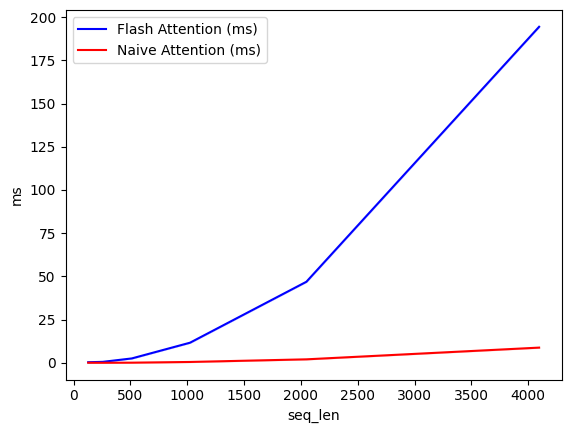

In [15]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['seq_len'],
        x_vals=[128, 256, 512, 1024, 2048, 4096],
        line_arg='provider',
        line_vals=['flash', 'naive'],
        line_names=['Flash Attention', 'Naive Attention'],
        styles=[('blue', '-'), ('red', '-')],
        ylabel='ms',
        plot_name='Attention Runtime vs Sequence Length',
        args={'B': 1, 'H': 4, 'D': 64},
    )
)
def benchmark_runtime(B, H, D, seq_len, provider):
    Q = torch.randn(B, H, seq_len, D, device='cuda', dtype=torch.float16)
    K = torch.randn(B, H, seq_len, D, device='cuda', dtype=torch.float16)
    V = torch.randn(B, H, seq_len, D, device='cuda', dtype=torch.float16)
    quantiles = [0.5, 0.2, 0.8]

    if provider == 'flash':
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: flash_attention(Q, K, V, causal=True), quantiles=quantiles
        )
    elif provider == 'naive':
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: naive_attention(Q, K, V, causal=True), quantiles=quantiles
        )

    return ms, max_ms, min_ms

benchmark_runtime.run(print_data=True, save_path=PLOTS_DIR)

### Runtime Results Analysis

Our Flash Attention kernel is slower than naive attention at all sequence lengths.
This is expected for a teaching implementation — naive attention calls into
cuBLAS and cuDNN internally, which are assembly-level optimized. Our kernel
uses no software pipelining and has suboptimal memory access patterns.

The value of this implementation is understanding the algorithm — online softmax,
tiled KV iteration, running max and sum — not beating PyTorch's internals.
A production Flash Attention (like the Triton tutorial kernel) adds pipelining
and careful memory layout to close this gap.

The real advantage of Flash Attention is memory — it never materializes the
N×N attention matrix. We demonstrate this next.

### Benchmark 2: Peak VRAM vs Sequence Length

Flash Attention never writes the N×N attention matrix to global memory.
Naive attention allocates it fully. This difference becomes critical at
long sequence lengths where the N×N matrix alone consumes gigabytes of VRAM.

Seq Len    Flash (MB)      Naive (MB)      Reduction
--------------------------------------------------
128        9.31            9.58            1.03x
256        9.57            10.68           1.12x
512        10.09           14.55           1.44x
1024       11.14           28.97           2.60x
2048       13.24           84.54           6.39x
4096       17.43           302.65          17.36x


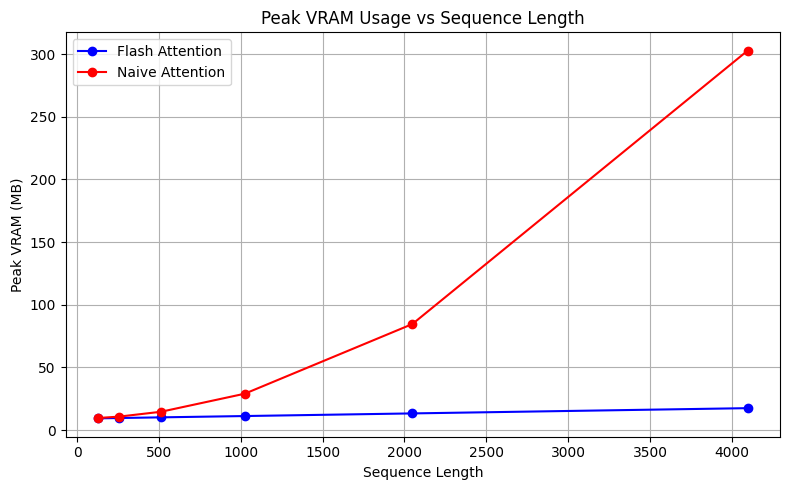

Plot saved to /content/drive/MyDrive/triton-llm-kernels-lab/plots/02_flash_attention


In [16]:
def measure_vram(fn):
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    fn()
    torch.cuda.synchronize()
    return torch.cuda.max_memory_allocated() / 1e6  # MB


seq_lens = [128, 256, 512, 1024, 2048, 4096]
B, H, D = 1, 4, 64

flash_vram = []
naive_vram = []

for seq_len in seq_lens:
    Q = torch.randn(B, H, seq_len, D, device='cuda', dtype=torch.float16)
    K = torch.randn(B, H, seq_len, D, device='cuda', dtype=torch.float16)
    V = torch.randn(B, H, seq_len, D, device='cuda', dtype=torch.float16)

    flash_vram.append(measure_vram(lambda: flash_attention(Q, K, V, causal=True)))
    naive_vram.append(measure_vram(lambda: naive_attention(Q, K, V, causal=True)))

# print results
print(f"{'Seq Len':<10} {'Flash (MB)':<15} {'Naive (MB)':<15} {'Reduction'}")
print("-" * 50)
for i, seq_len in enumerate(seq_lens):
    reduction = naive_vram[i] / flash_vram[i]
    print(f"{seq_len:<10} {flash_vram[i]:<15.2f} {naive_vram[i]:<15.2f} {reduction:.2f}x")

# plot
plt.figure(figsize=(8, 5))
plt.plot(seq_lens, flash_vram, 'b-o', label='Flash Attention')
plt.plot(seq_lens, naive_vram, 'r-o', label='Naive Attention')
plt.xlabel('Sequence Length')
plt.ylabel('Peak VRAM (MB)')
plt.title('Peak VRAM Usage vs Sequence Length')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'vram_vs_seqlen.png'), dpi=150)
plt.show()
print(f'Plot saved to {PLOTS_DIR}')

### VRAM Results Analysis

VRAM usage confirms the theoretical prediction. Naive attention grows quadratically
with sequence length — the N×N matrix dominates memory at long contexts.
Flash Attention grows linearly, never materializing the N×N matrix.

At seq_len=4096 Flash Attention uses 17x less VRAM. At seq_len=32768 naive
attention would require ~19GB for this configuration alone — impossible on a
15.6GB T4. Flash Attention makes long context inference feasible on real hardware.

### Benchmark 3: Maximum Sequence Length Before OOM

Pushing both implementations to their memory limits to find the maximum
sequence length each can handle on a 15.6GB T4.

In [18]:
B, H, D = 2, 8, 64  # more realistic config — closer to real transformer

print('Flash Attention:')
flash_max = max_seq_len_before_oom(flash_attention, B, H, D, start=512, step=512, max_seq=32768)

torch.cuda.empty_cache()

print('\nNaive Attention:')
naive_max = max_seq_len_before_oom(naive_attention, B, H, D, start=512, step=512, max_seq=32768)

print(f'\nFlash Attention max seq_len : {flash_max}')
print(f'Naive Attention max seq_len : {naive_max}')
if naive_max > 0:
    print(f'Flash Attention supports {flash_max // naive_max}x longer sequences')

Flash Attention:
  seq_len=512: ✅
  seq_len=1024: ✅
  seq_len=1536: ✅
  seq_len=2048: ✅
  seq_len=2560: ✅
  seq_len=3072: ✅
  seq_len=3584: ✅
  seq_len=4096: ✅
  seq_len=4608: ✅
  seq_len=5120: ✅
  seq_len=5632: ✅
  seq_len=6144: ✅
  seq_len=6656: ✅
  seq_len=7168: ✅
  seq_len=7680: ✅
  seq_len=8192: ✅
  seq_len=8704: ✅
  seq_len=9216: ✅
  seq_len=9728: ✅
  seq_len=10240: ✅
  seq_len=10752: ✅
  seq_len=11264: ✅
  seq_len=11776: ✅
  seq_len=12288: ✅
  seq_len=12800: ✅
  seq_len=13312: ✅
  seq_len=13824: ✅
  seq_len=14336: ✅
  seq_len=14848: ✅
  seq_len=15360: ✅
  seq_len=15872: ✅
  seq_len=16384: ✅
  seq_len=16896: ✅
  seq_len=17408: ✅
  seq_len=17920: ✅
  seq_len=18432: ✅
  seq_len=18944: ✅
  seq_len=19456: ✅
  seq_len=19968: ✅
  seq_len=20480: ✅
  seq_len=20992: ✅
  seq_len=21504: ✅
  seq_len=22016: ✅
  seq_len=22528: ✅
  seq_len=23040: ✅
  seq_len=23552: ✅
  seq_len=24064: ✅
  seq_len=24576: ✅
  seq_len=25088: ✅
  seq_len=25600: ✅
  seq_len=26112: ✅
  seq_len=26624: ✅
  seq_len=27136

### OOM Results Analysis

On a 15.6GB T4 with B=2, H=8, D=64:
- Naive Attention OOMs at seq_len=12800
- Flash Attention handles seq_len=32768 with room to spare

Flash Attention supports 2.6x longer sequences on the same hardware.
The gap widens further at larger batch sizes and more heads — on a
real Llama 3 8B config (B=4, H=32), naive attention would OOM much earlier.

## Summary

This notebook implements Flash Attention from scratch in Triton and compares
it against naive attention across three metrics.

**Runtime:** Our teaching implementation is slower than naive attention — naive
attention calls into cuBLAS and cuDNN internally. A production Flash Attention
kernel (with software pipelining and autotuned tile sizes) closes this gap.
The algorithm is correct, the implementation is not yet optimized.

**VRAM:** Flash Attention uses 17x less memory at seq_len=4096. This gap grows
quadratically — naive attention memory scales as O(N²), Flash Attention as O(N).

**Max Sequence Length:** On a 15.6GB T4, naive attention OOMs at seq_len=12800.
Flash Attention handles seq_len=32768 with room to spare — 2.6x longer sequences
on identical hardware.

**Key insight:** Flash Attention's advantage is not compute speed — it is memory.
By never materializing the N×N attention matrix, it makes long context inference
feasible on real hardware. This is why every production inference engine
(vLLM, TensorRT-LLM, SGLang) uses Flash Attention as a non-negotiable baseline.